# Interactive Plots with Plotly
v.ekc

Static plots are great for reports, but what if the reader could *explore* the data themselves? Today we look at three tools that make that possible: **Plotly Express** for hover, zoom, and animation, and **ipywidgets** for sliders and dropdowns that control your plots in real time.

| Section | Topic |
|---------|-------|
| 1 | Setup |
| 2 | Plotly Express: Hover, Zoom, and Facets |
| 3 | Animations with Plotly: Gapminder |
| 4 | ipywidgets: Sliders and Dropdowns |
| 5 | Combining Widgets with Plotly |
| 6 | Open Exploration: Gapminder |
| Appendix | Quick Reference |

---
## 1. Setup

In [31]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

---
## 2. Plotly Express: Hover, Zoom, and Facets

Every Plotly Express plot comes with **hover**, **zoom**, and **pan** built in, for free. The API is almost identical to Seaborn, so the learning curve is tiny. Swap `sns` for `px`, pass in your DataFrame, and you get an interactive figure back.

### 📋 Board Reference

| Function | What it does |
|----------|--------------|
| `px.line(x=, y=)` | Interactive line plot |
| `px.scatter(df, x=, y=, color=)` | Interactive scatter |
| `px.histogram(df, x=)` | Interactive histogram |
| `px.imshow(matrix)` | Interactive heatmap (e.g., correlation matrix) |
| `hover_data=[...]` | Add extra columns to the hover tooltip |
| `hover_name='col'` | Bold label at the top of the tooltip |
| `facet_col='col'` | Small multiples arranged in columns |
| `facet_row='col'` | Small multiples arranged in rows |
| `fig.show()` | Render the interactive figure |

In [32]:
import plotly.express as px

### Line plots

The simplest starting point, and already interactive. Hover over any point to read exact values; click and drag to zoom.

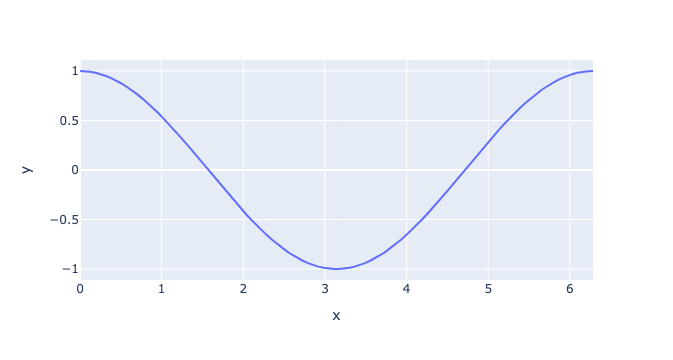

In [3]:
# Basic interactive line plot
t = np.linspace(0, 2*np.pi, 100)
fig = px.line(x=t, y=np.cos(t))
fig.show()

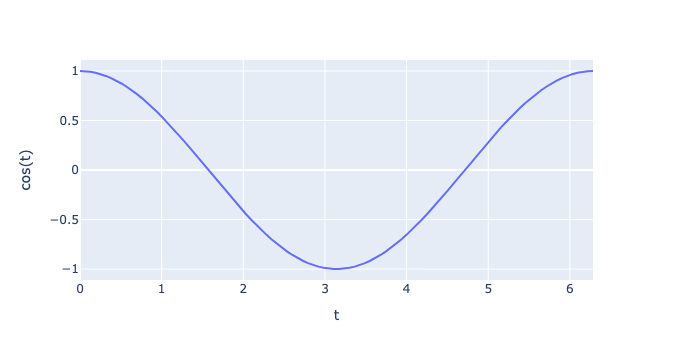

In [4]:
# Add human-readable axis labels
fig = px.line(x=t, y=np.cos(t), labels={'x': 't', 'y': 'cos(t)'})
fig.show()

### Scatter plots

Scatter plots are where hover really shines. You can pack extra context into the tooltip without cluttering the visual.

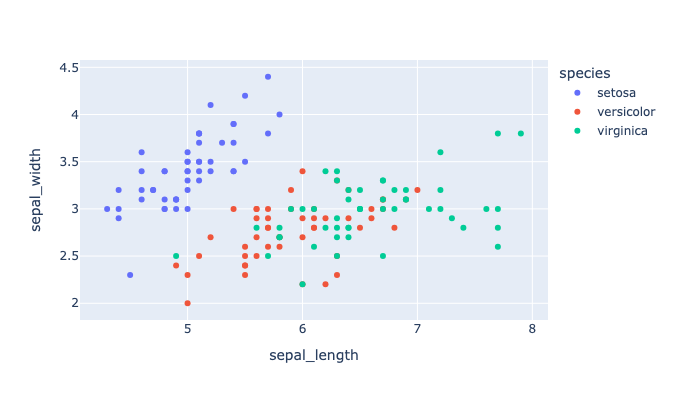

In [5]:
# Simple scatter, color by species
df = px.data.iris()   # plotly has built-in datasets (like seaborn)
fig = px.scatter(df, x="sepal_length", y="sepal_width",
                 color='species', width=500, height=400)
fig.show()

In [6]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


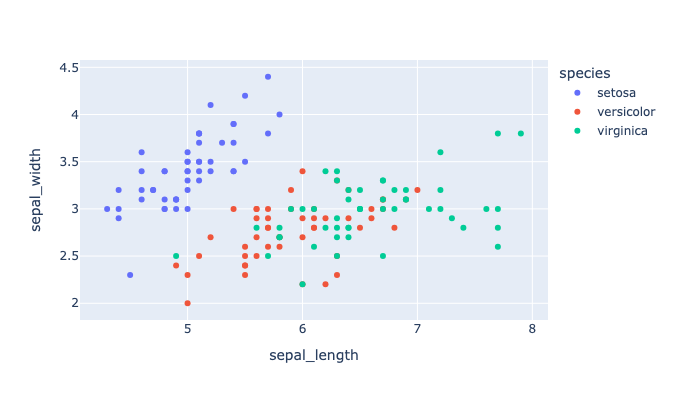

In [7]:
# Add extra columns to the hover tooltip
fig = px.scatter(df, x="sepal_length", y="sepal_width", color='species',
                 width=500, height=400,
                 hover_data=['petal_length', 'petal_width'])
fig.show()

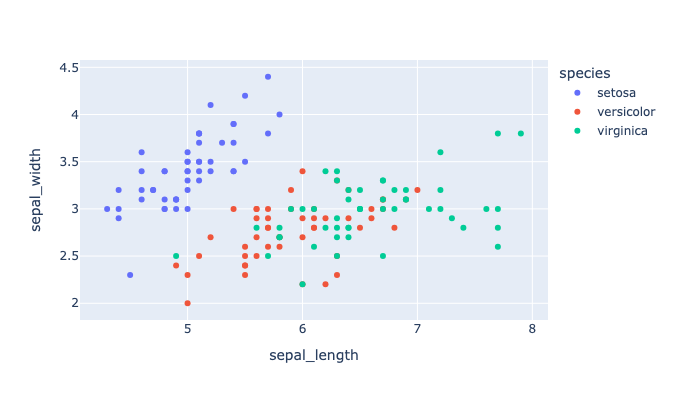

In [8]:
# hover_name puts a bold label at the top of the tooltip
fig = px.scatter(df, x="sepal_length", y="sepal_width", color='species',
                 width=500, height=400,
                 hover_data=['petal_length', 'petal_width'],
                 hover_name='species_id')
fig.show()

### Facets

`facet_col` gives you small multiples: one panel per group value. Each panel is still fully interactive.

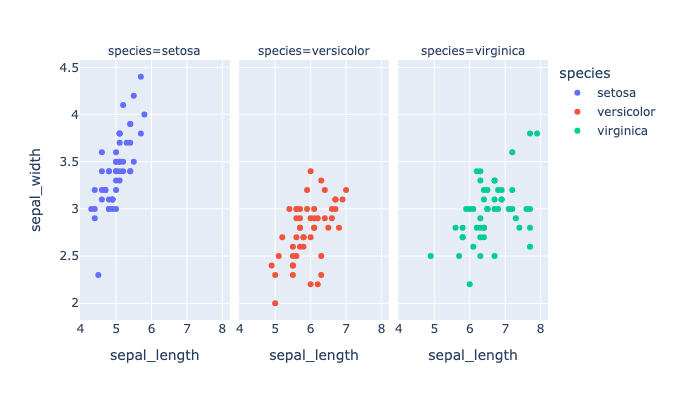

In [9]:
# One interactive panel per species
fig = px.scatter(df, x="sepal_length", y="sepal_width", color='species',
                 width=1000, height=400,
                 hover_data=['petal_length', 'petal_width'],
                 facet_col='species')
fig.show()

### Histograms and heatmaps

Both work exactly like their Seaborn counterparts, with hover included.

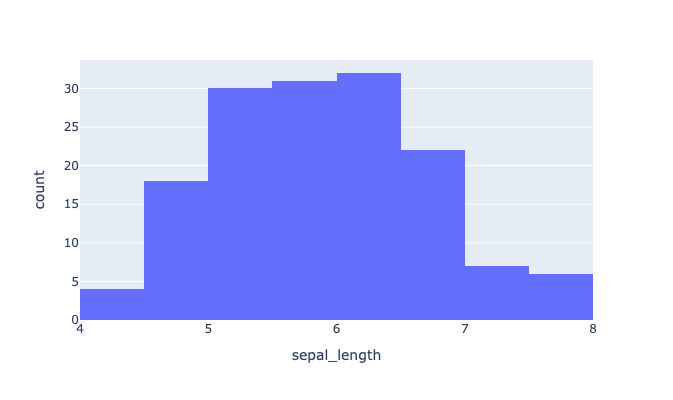

In [10]:
fig = px.histogram(df, x="sepal_length", width=500, height=400)
fig.show()

`px.imshow` is the go-to for correlation matrices. `text_auto='.2f'` stamps the correlation value directly onto each cell, so you do not need to squint at the colorbar.

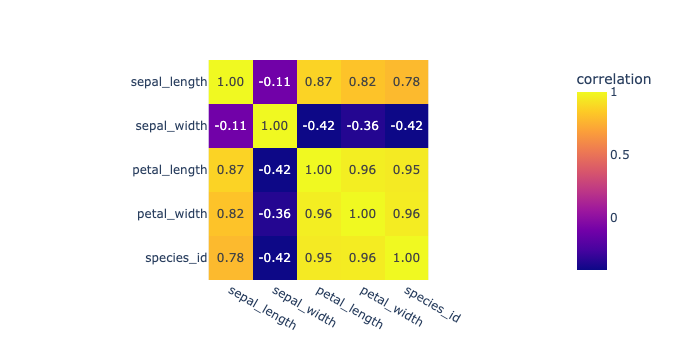

In [11]:
fig = px.imshow(
    df.corr(numeric_only=True),
    color_continuous_scale='plasma',
    labels={'color': 'correlation'},
    text_auto='.2f'
)
fig.show()

---
### Try It 1: Plotly Express Basics 😊

Use the `iris` dataset (`df`) loaded above.

1. Build a scatter of `petal_length` vs `petal_width`, colored by `species`. Add `hover_name='species'`. What changes in the tooltip compared to the default?

2. Make a histogram of `petal_length`, using `color='species'` to overlay the three distributions. What do you notice about how the species separate?

3. Add `facet_row='species'` to the histogram from #2 (instead of overlaying). When is faceting clearer than overlaying?

4. **Your choice:** try any function from the Board Reference table you have not used yet. Use the iris dataset or swap in `px.data.tips()` for something different.

In [ ]:
# 1. Scatter petal_length vs petal_width with hover_name


In [ ]:
# 2. Histogram of petal_length colored by species


In [ ]:
# 3. facet_row='species' on the histogram


In [ ]:
# 4. Your choice


<details>
<summary>💡 Possible answers: click to peek</summary>
<br>

*The species distributions in petal size are much more separated than in sepal size, a useful insight for classification.*

```python
# 1.
fig = px.scatter(df, x='petal_length', y='petal_width',
                 color='species', hover_name='species')
fig.show()

# 2.
fig = px.histogram(df, x='petal_length', color='species',
                   width=600, height=400)
fig.show()

# 3.
fig = px.histogram(df, x='petal_length', color='species',
                   facet_row='species', width=600, height=500)
fig.show()

# 4. Tips dataset: box plot by day
tips = px.data.tips()
fig = px.box(tips, x='day', y='total_bill', color='sex')
fig.show()
```

</details>

---
## 3. Animations with Plotly: Gapminder

In 2006, Hans Rosling gave a TED talk where he animated a scatter of GDP vs life expectancy across decades, and it changed how people think about global development. Plotly makes the same animation *one argument*: `animation_frame='year'`.

First, let us wrangle the Gapminder dataset into tidy form.

### ETL

The raw CSV is in wide format: one column per `variable_year` combination. We need to melt, split, then pivot to get tidy data.

In [12]:
df_gap = pd.read_csv('gapminder_all.csv')
df_gap.head()

,continent,country,gdpPercap_1952,gdpPercap_1957,gdpPercap_1962,gdpPercap_1967,gdpPercap_1972,gdpPercap_1977,gdpPercap_1982,gdpPercap_1987,...,pop_1962,pop_1967,pop_1972,pop_1977,pop_1982,pop_1987,pop_1992,pop_1997,pop_2002,pop_2007
0,Africa,Algeria,2449.008185,3013.976023,2550.816880,3246.991771,4182.663766,4910.416756,5745.160213,5681.358539,...,11000948.0,12760499.0,14760787.0,17152804.0,20033753.0,23254956.0,26298373.0,29072015.0,31287142,33333216
1,Africa,Angola,3520.610273,3827.940465,4269.276742,5522.776375,5473.288005,3008.647355,2756.953672,2430.208311,...,4826015.0,5247469.0,5894858.0,6162675.0,7016384.0,7874230.0,8735988.0,9875024.0,10866106,12420476
2,Africa,Benin,1062.752200,959.601080,949.499064,1035.831411,1085.796879,1029.161251,1277.897616,1225.856010,...,2151895.0,2427334.0,2761407.0,3168267.0,3641603.0,4243788.0,4981671.0,6066080.0,7026113,8078314
3,Africa,Botswana,851.241141,918.232535,983.653976,1214.709294,2263.611114,3214.857818,4551.142150,6205.883850,...,512764.0,553541.0,619351.0,781472.0,970347.0,1151184.0,1342614.0,1536536.0,1630347,1639131
4,Africa,Burkina Faso,543.255241,617.183465,722.512021,794.826560,854.735976,743.387037,807.198586,912.063142,...,4919632.0,5127935.0,5433886.0,5889574.0,6634596.0,7586551.0,8878303.0,10352843.0,12251209,14326203


In [13]:
# Melt: one row per (country, variable_year) pair
long_df = df_gap.melt(id_vars=['continent', 'country'])
long_df.head()

,continent,country,variable,value
0,Africa,Algeria,gdpPercap_1952,2449.008185
1,Africa,Angola,gdpPercap_1952,3520.610273
2,Africa,Benin,gdpPercap_1952,1062.752200
3,Africa,Botswana,gdpPercap_1952,851.241141
4,Africa,Burkina Faso,gdpPercap_1952,543.255241


In [14]:
# Split 'gdpPercap_1952' into var='gdpPercap', year='1952'
long_df[['var', 'year']] = long_df.variable.str.split('_', expand=True)
long_df.drop(columns='variable', inplace=True)
long_df.head()

,continent,country,value,var,year
0,Africa,Algeria,2449.008185,gdpPercap,1952
1,Africa,Angola,3520.610273,gdpPercap,1952
2,Africa,Benin,1062.752200,gdpPercap,1952
3,Africa,Botswana,851.241141,gdpPercap,1952
4,Africa,Burkina Faso,543.255241,gdpPercap,1952


In [15]:
# Pivot: each variable gets its own column
tidy_df = long_df.pivot_table(
    index=['continent', 'country', 'year'],
    columns='var', values='value'
).reset_index()
tidy_df.head()

var,continent,country,year,gdpPercap,lifeExp,pop
0,Africa,Algeria,1952,2449.008185,43.077,9279525.0
1,Africa,Algeria,1957,3013.976023,45.685,10270856.0
2,Africa,Algeria,1962,2550.816880,48.303,11000948.0
3,Africa,Algeria,1967,3246.991771,51.407,12760499.0
4,Africa,Algeria,1972,4182.663766,54.518,14760787.0


In [16]:
tidy_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   continent  1704 non-null   str    
 1   country    1704 non-null   str    
 2   year       1704 non-null   str    
 3   gdpPercap  1704 non-null   float64
 4   lifeExp    1704 non-null   float64
 5   pop        1704 non-null   float64
dtypes: float64(3), str(3)
memory usage: 80.0 KB


In [17]:
tidy_df['year'] = tidy_df.year.astype(int)

### Why not just use Seaborn?

With Seaborn, showing *change over time* means faceting: one small panel per year. That is 12 tiny panels for 12 years of data.

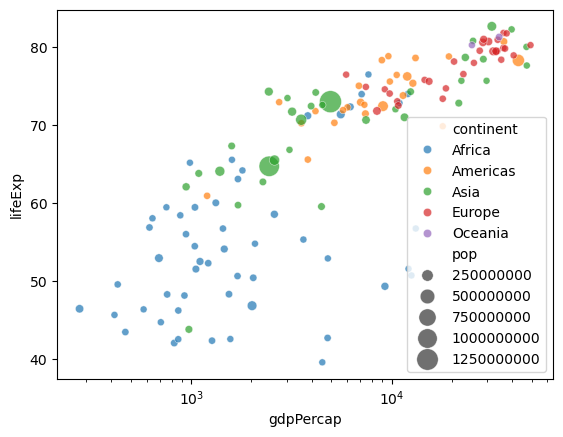

In [18]:
# One year is fine in Seaborn
sns.scatterplot(data=tidy_df[tidy_df['year'] == 2007],
                x='gdpPercap', y='lifeExp',
                size='pop', sizes=(25, 250),
                hue='continent', alpha=0.7)
plt.xscale('log')

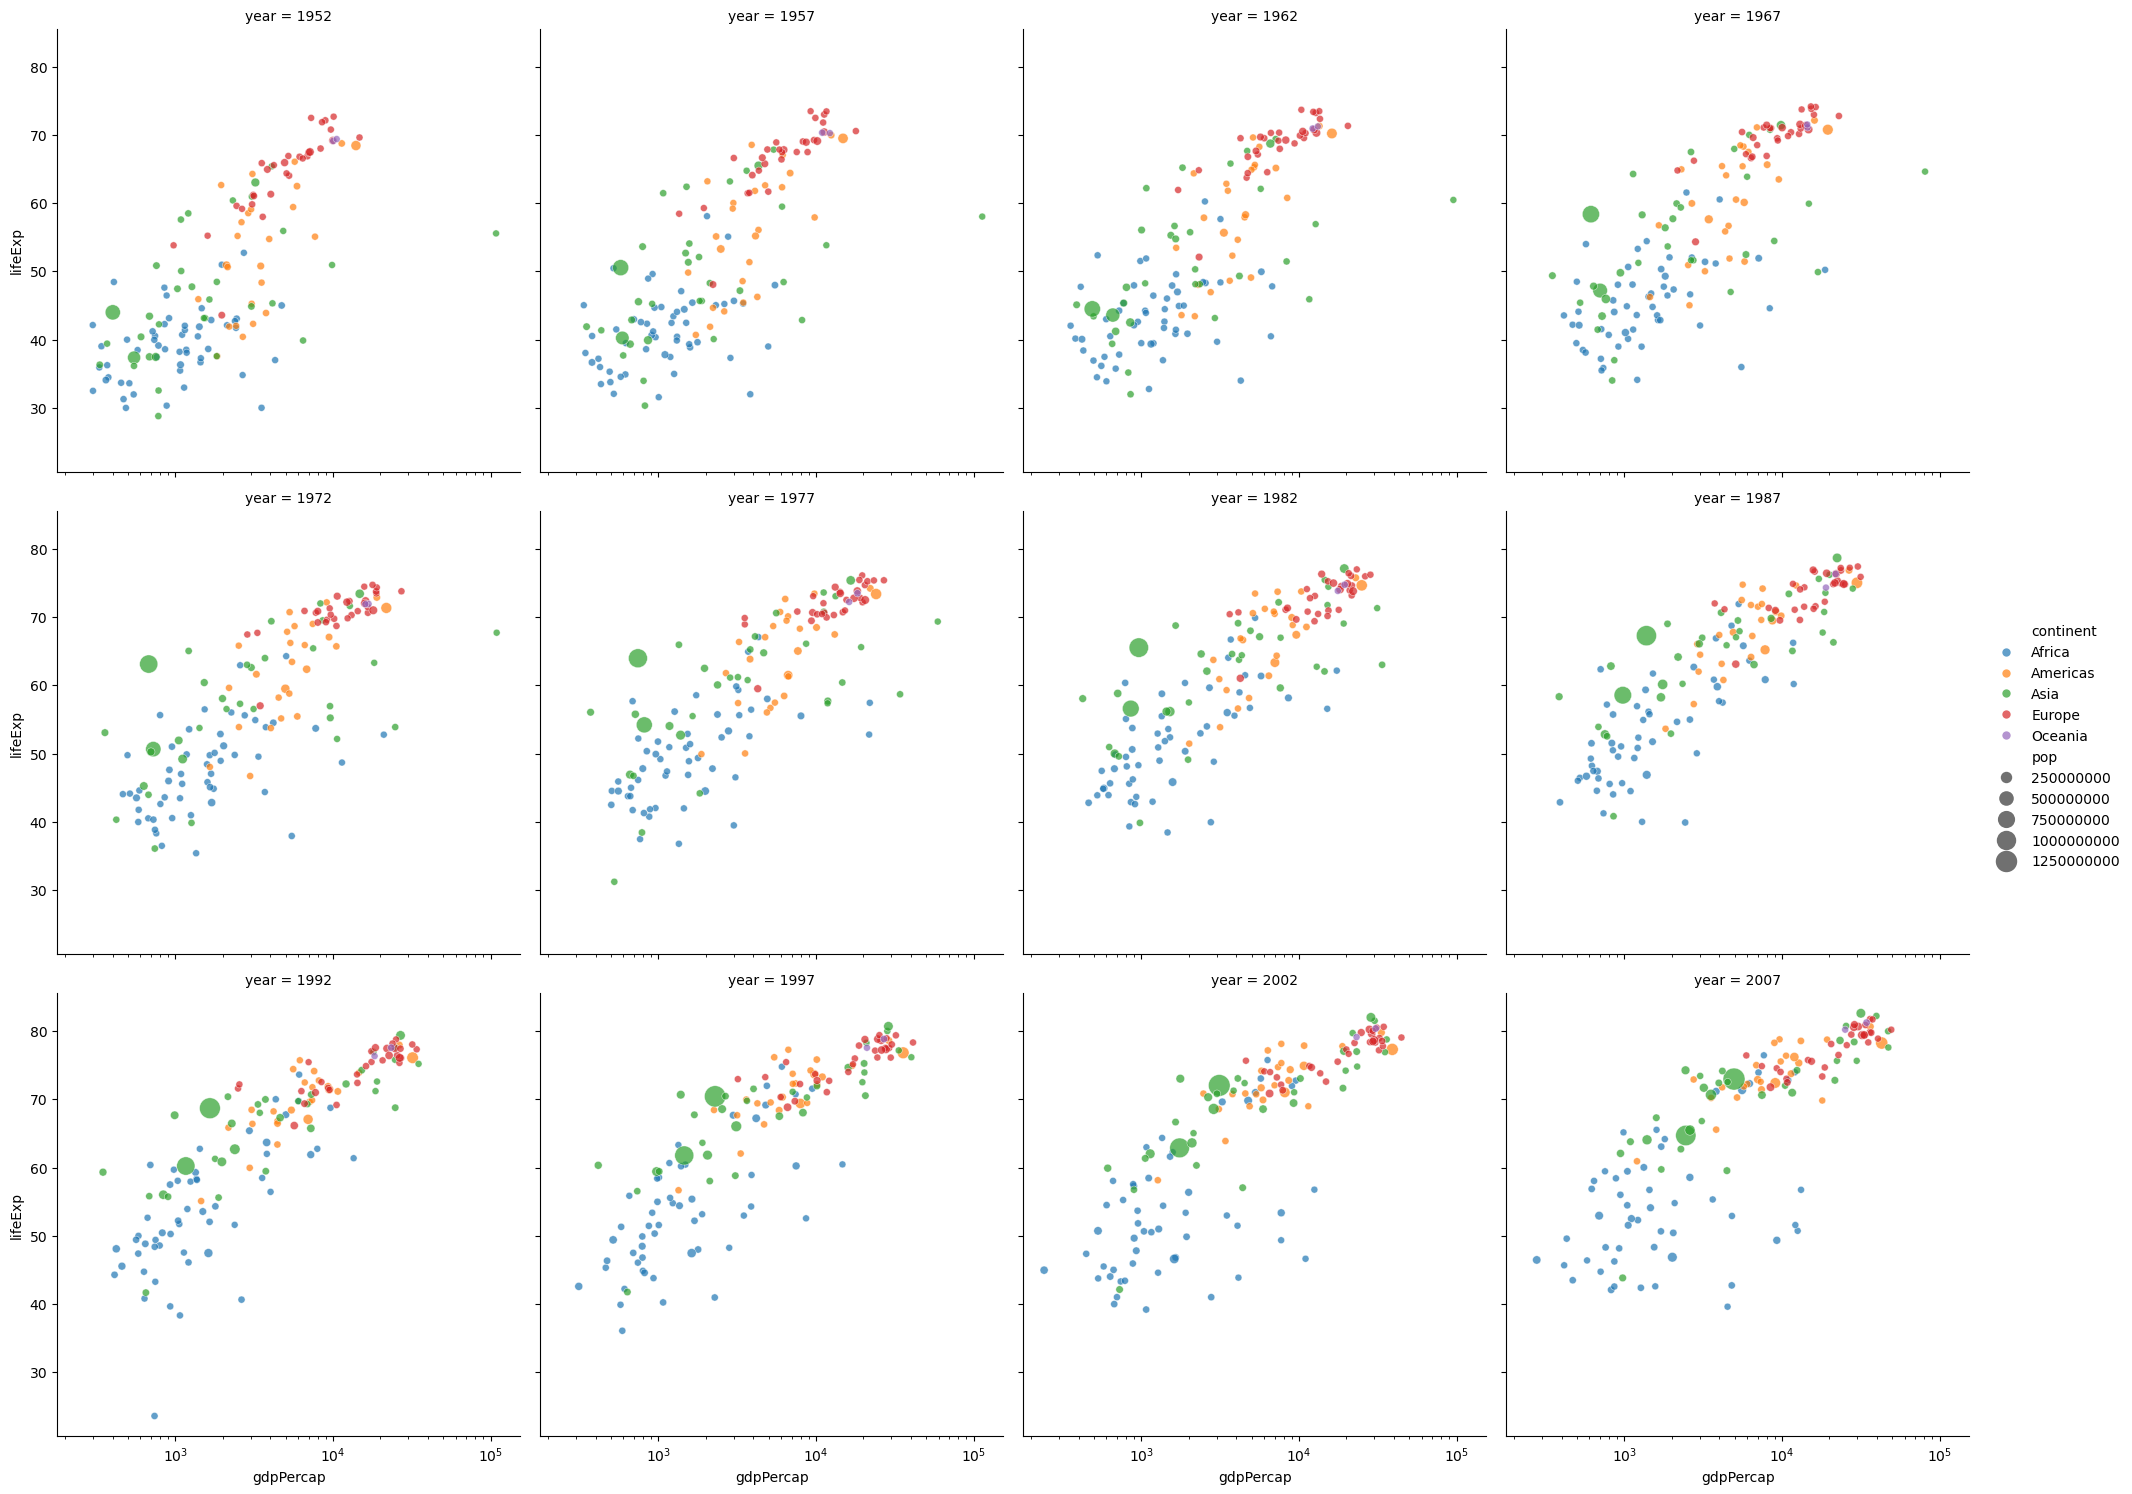

In [19]:
# All years = 12 small panels, hard to follow the trend
sns.relplot(data=tidy_df, x='gdpPercap', y='lifeExp',
            size='pop', sizes=(25, 250),
            hue='continent', alpha=0.7,
            col='year', col_wrap=4)
plt.xscale('log')

> **That is 12 panels just to show change over time!** The trend is there, but following a single country across panels is nearly impossible. 😬
>
> With Plotly, `animation_frame='year'` collapses all 12 panels into a single animated plot with a play button. Let us see it.

### Interactive scatter: one year

Even the static version is more useful than Seaborn. Hover shows country names, and you can zoom into any region.

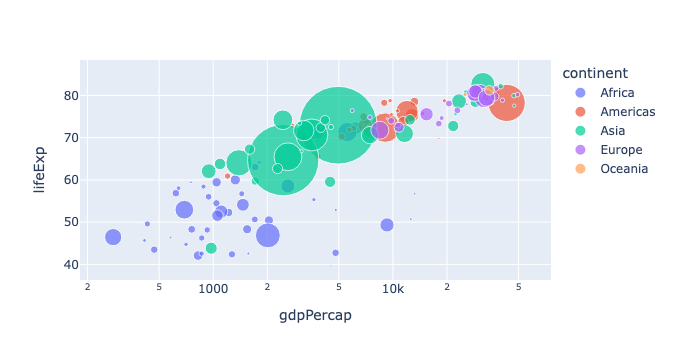

In [20]:
# Static but interactive: hover shows country name
fig = px.scatter(tidy_df[tidy_df['year'] == 2007],
                 x="gdpPercap", y="lifeExp",
                 size="pop", color="continent",
                 log_x=True, size_max=55,
                 hover_name='country')
fig.show()

### Animated scatter: `animation_frame`

Add `animation_frame='year'` and Plotly builds the full time-lapse. Hit play and watch 55 years of global development unfold. `range_x` and `range_y` keep the axes fixed so the animation reads correctly.

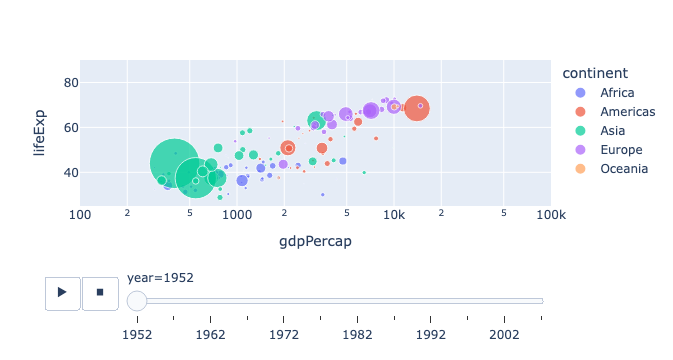

In [21]:
# The Hans Rosling plot: one extra argument
fig = px.scatter(tidy_df, x="gdpPercap", y="lifeExp",
                 size="pop", color="continent",
                 hover_name="country",
                 animation_frame="year",
                 log_x=True, size_max=55,
                 range_x=[100, 100000], range_y=[25, 90])
fig.show()

### Animated bar charts

`animation_frame` works on bar charts too. Here each bar is a country. Watch population shift as the animation plays.

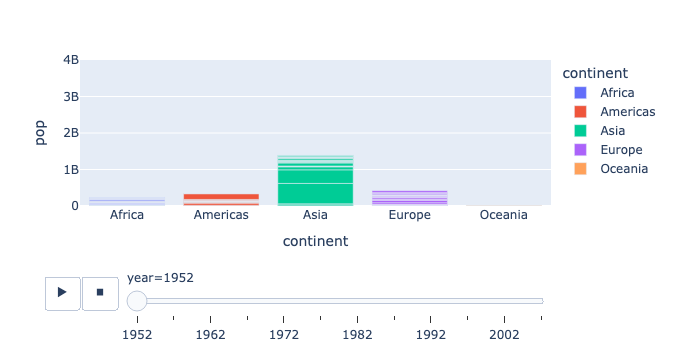

In [22]:
# Animated bar: population by continent, each bar = one country
fig = px.bar(tidy_df, x="continent", y="pop",
             color="continent",
             animation_frame="year",
             hover_name='country',
             range_y=[0, 4_000_000_000])
fig.show()

---
### Try It 2: Animate! 😊

Use `tidy_df` (columns: `continent`, `country`, `year`, `gdpPercap`, `lifeExp`, `pop`).

1. Build an animated scatter with `lifeExp` on x and `pop` on y, using `log_y=True`. Set `range_x` and `range_y` so the animation does not jump around. What story does this version of the data tell?

2. Build an animated bar chart that shows **average `lifeExp`** by continent over time. (Hint: `.groupby(['continent','year'])['lifeExp'].mean().reset_index()`) Which continent saw the largest gains?

3. **WiLdCaRd:** build any animated Plotly plot from `tidy_df`. Requirements: at least 2 aesthetics and `animation_frame='year'`.

*Your interpretation: (double-click to edit)*

In [ ]:
# 1. Animated scatter: lifeExp vs pop


In [ ]:
# 2. Animated bar: avg lifeExp by continent


In [ ]:
# 3. WiLdCaRd


<details>
<summary>💡 Possible answers: click to peek</summary>
<br>

*For #2, group before passing to px.bar. Plotly's bar will sum `pop` by default, which is not what you want for life expectancy.*

```python
# 1.
fig = px.scatter(tidy_df, x='lifeExp', y='pop',
                 color='continent', size='gdpPercap',
                 hover_name='country',
                 animation_frame='year',
                 log_y=True, size_max=40,
                 range_x=[25, 90], range_y=[1e5, 2e9])
fig.show()

# 2.
avg_life = tidy_df.groupby(['continent', 'year'])['lifeExp'].mean().reset_index()
fig = px.bar(avg_life, x='continent', y='lifeExp',
             color='continent',
             animation_frame='year',
             range_y=[0, 85])
fig.show()

# 3. Example: animated line showing avg gdpPercap by continent
avg_gdp = tidy_df.groupby(['continent', 'year'])['gdpPercap'].mean().reset_index()
fig = px.line(avg_gdp, x='year', y='gdpPercap',
              color='continent', markers=True,
              animation_frame='year',
              range_y=[0, 35000])
fig.show()
```

</details>

---
## 4. ipywidgets: Sliders and Dropdowns

Plotly gives you hover and animation out of the box. **ipywidgets** goes further: it lets you wire up sliders and dropdowns that call any Python function when they change. Any function: plot, calculation, anything.

### 📋 Board Reference

| Widget | Code | Use case |
|--------|------|----------|
| Integer slider | `widgets.IntSlider()` | Discrete integer values |
| Float slider | `widgets.FloatSlider(value=, min=, max=, step=)` | Continuous values |
| Dropdown | `widgets.Dropdown(options=[...], description='Label:')` | Categorical choices |
| Dict dropdown | `widgets.Dropdown(options={'label': value})` | Human-readable labels |
| Connect to function | `interact(func, param=widget)` | Re-runs function on change |

In [33]:
from ipywidgets import interact
import ipywidgets as widgets

### `interact()`: the fastest path

`interact(func, param=widget)` runs `func` every time the widget changes. The simplest widget is just a number: `interact` infers a slider automatically.

In [24]:
def cube(x):
    return x**3

interact(cube, x=3);

interactive(children=(IntSlider(value=3, description='x', max=9, min=-3), Output()), _dom_classes=('widget-int…

### Customizing sliders

When you need more control over the range and step size, build the slider explicitly.

In [25]:
widgets.IntSlider()

IntSlider(value=0)

In [26]:
widgets.FloatSlider()

FloatSlider(value=0.0)

In [27]:
widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='My slider:')

FloatSlider(value=1.0, description='My slider:', max=2.0, min=0.1)

Here is a practical use: a slider that changes the *frequency* of a sine wave. This kind of tool is great for building intuition about a function.

In [34]:
def sin_func(frequency):
    x = np.linspace(0, 10, 100)
    plt.plot(x, np.sin(frequency * x))
    plt.xlabel('x')
    plt.ylabel('sin(f*x)')
    plt.show()

# Create a slider widget using widgets.FloatSlider
slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=2.0,
    step=0.1,
    description='f:'
)

interact(sin_func, frequency=slider);

interactive(children=(FloatSlider(value=1.0, description='f:', max=2.0, min=0.1), Output()), _dom_classes=('wi…

### Dropdowns

Dropdowns let the user choose from a list: strings, numbers, or any Python object. Using a `dict` as `options` gives you human-readable labels.

In [35]:
widgets.Dropdown(options=[1, 2, 3], description='Number:')

Dropdown(description='Number:', options=(1, 2, 3), value=1)

In [36]:
# Dict options: human-readable label maps to actual value
w = widgets.Dropdown(options={'pi': 3.14, 'e': 2.72}, description='Number:')
w

Dropdown(description='Number:', options={'pi': 3.14, 'e': 2.72}, value=3.14)

In [37]:
w.value   # the selected value

3.14

---
### Try It 3: Build a Widget 😊

1. Write a function `power(x, n)` that computes `x**n` and prints the result. Use `interact()` with a float slider for `x` (0.1 to 5.0) and an int slider for `n` (1 to 5). What happens when `n=1`? When `n=0`?

2. Modify `sin_func` above to use `px.line` instead of `plt.plot`. Does it feel more interactive than the Matplotlib version?

3. Create a dropdown with options `['gdpPercap', 'lifeExp', 'pop']` and use `interact()` to print the currently selected column name. (Hint: `interact(print, col=dropdown)`) This is the building block for the next section!

In [ ]:
# 1. power(x, n) with two sliders


In [ ]:
# 2. sin_func using px.line


In [ ]:
# 3. Gapminder column dropdown


<details>
<summary>💡 Possible answers: click to peek</summary>
<br>

*Once you have a dropdown printing a value, swapping `print` for a plot function is all it takes.*

```python
# 1.
def power(x, n):
    print(f"{x}^{n} = {x**n:.4f}")

interact(power,
         x=widgets.FloatSlider(value=2.0, min=0.1, max=5.0, step=0.1),
         n=widgets.IntSlider(value=2, min=0, max=5));

# 2.
def sin_px(frequency):
    x = np.linspace(0, 10, 200)
    fig = px.line(x=x, y=np.sin(frequency * x),
                  labels={'x': 'x', 'y': 'sin(f·x)'},
                  width=600, height=350)
    fig.show()

slider = widgets.FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='f:')
interact(sin_px, frequency=slider);

# 3.
col_dd = widgets.Dropdown(options=['gdpPercap', 'lifeExp', 'pop'], description='Column:')
interact(print, col=col_dd);
```

</details>

---
## 5. Combining Widgets with Plotly

Now the fun part: hook a dropdown or slider up to a Plotly figure. Every time the widget changes, a fresh figure renders, giving the user real-time control over what they see.

### A simple trig example

Start small: a dropdown that switches between sine and cosine.

In [38]:
x = np.linspace(0, 10, 100)

def update_trig(function):
    if function == 'sine':
        fig = px.line(x=x, y=np.sin(x), labels={'y': 'sin(x)', 'x': 'x'})
    else:
        fig = px.line(x=x, y=np.cos(x), labels={'y': 'cos(x)', 'x': 'x'})
    fig.show()

dropdown = widgets.Dropdown(options={'sin(x)': 'sine', 'cos(x)': 'cosine'},
                            description='Function:')
interact(update_trig, function=dropdown);

interactive(children=(Dropdown(description='Function:', options={'sin(x)': 'sine', 'cos(x)': 'cosine'}, value=…

### Adjustable axes: iris dataset

Two dropdowns that let the user pick the x- and y-axis. Every combination re-renders the scatter instantly.

In [39]:
df.head()   # iris dataset from earlier

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [40]:
iris_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

def update_scatter(x_axis, y_axis):
    fig = px.scatter(df, x=x_axis, y=y_axis, color='species',
                     height=500, width=700)
    fig.show()

x_dd = widgets.Dropdown(options=iris_cols, description='X Axis:')
y_dd = widgets.Dropdown(options=iris_cols, value='sepal_width', description='Y Axis:')
interact(update_scatter, x_axis=x_dd, y_axis=y_dd);

interactive(children=(Dropdown(description='X Axis:', options=('sepal_length', 'sepal_width', 'petal_length', …

### Widgets + animation

You can combine `animation_frame` with a dropdown. Let the user choose a display option while the animation still plays.

In [41]:
def update_gapminder(log_scale):
    x_range = [100, 100000] if log_scale else [0, 45000]
    fig = px.scatter(tidy_df, x="gdpPercap", y="lifeExp",
                     size="pop", color="continent",
                     hover_name="country",
                     animation_frame="year",
                     log_x=log_scale,
                     size_max=55,
                     range_x=x_range,
                     range_y=[25, 90])
    fig.show()

scale_dd = widgets.Dropdown(options={'Log scale': True, 'Linear scale': False},
                            description='X scale:')
interact(update_gapminder, log_scale=scale_dd);

interactive(children=(Dropdown(description='X scale:', options={'Log scale': True, 'Linear scale': False}, val…

---
### Try It 4: Combine It All 😊

1. Extend the axis-selector scatter above to add a **third dropdown for `color`**. Options: `['species', 'species_id']`. How does coloring by `species_id` (numeric) look different from `species` (categorical)?

2. Modify `update_gapminder` to add a **continent dropdown** that filters `tidy_df` to only the selected continent before building the animation. Which continent shows the most variation within itself over time?

3. **WiLdCaRd:** build any interactive Plotly plot connected to at least one widget. It must use either `animation_frame` or at least 2 dropdowns. Use `tidy_df` or any `px.data.*` dataset.

*Your interpretation: (double-click to edit)*

In [ ]:
# 1. Three-dropdown iris scatter


In [ ]:
# 2. Gapminder animation + continent filter


In [ ]:
# 3. WiLdCaRd


<details>
<summary>💡 Possible answers: click to peek</summary>
<br>

*Numeric color scales are continuous (gradient), categorical ones are discrete. Use categorical for group membership, continuous for ordered quantities.*

```python
# 1.
iris_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

def update_scatter3(x_axis, y_axis, color_col):
    fig = px.scatter(df, x=x_axis, y=y_axis, color=color_col,
                     height=500, width=700)
    fig.show()

x_dd = widgets.Dropdown(options=iris_cols, description='X:')
y_dd = widgets.Dropdown(options=iris_cols, value='sepal_width', description='Y:')
c_dd = widgets.Dropdown(options=['species', 'species_id'], description='Color:')
interact(update_scatter3, x_axis=x_dd, y_axis=y_dd, color_col=c_dd);

# 2.
continents = tidy_df['continent'].unique().tolist()

def update_continent(continent):
    subset = tidy_df[tidy_df['continent'] == continent]
    fig = px.scatter(subset, x='gdpPercap', y='lifeExp',
                     size='pop', hover_name='country',
                     animation_frame='year',
                     log_x=True, size_max=55,
                     range_x=[100, 100000], range_y=[25, 90])
    fig.show()

continent_dd = widgets.Dropdown(options=continents, description='Continent:')
interact(update_continent, continent=continent_dd);
```

</details>

---
## 6. 🔬 Open Exploration: Gapminder

Use `tidy_df`: the tidied Gapminder dataset.

| Column | Description |
|--------|-------------|
| `continent` | World region |
| `country` | Country name |
| `year` | Year (1952 to 2007, every 5 years) |
| `gdpPercap` | GDP per capita (USD) |
| `lifeExp` | Life expectancy at birth (years) |
| `pop` | Population |

---
### Prompt 1: Distributions

Build an interactive plot that shows the distribution of **one variable** across countries, broken down by continent. Try `px.box` or `px.violin` with `animation_frame='year'`. What changes most over time?

In [ ]:
# Prompt 1


<details>
<summary>💡 One approach: click to peek</summary>
<br>

```python
fig = px.box(tidy_df, x='continent', y='lifeExp',
             color='continent',
             animation_frame='year',
             range_y=[20, 90])
fig.show()
```

</details>

---
### Prompt 2: Relationships

Build a widget-controlled scatter that lets you pick the **x-axis** column from `['gdpPercap', 'lifeExp', 'pop']`. Color by continent, include `hover_name='country'`, and use `log_x=True`. Which pairing tells the most interesting story?

In [ ]:
# Prompt 2


<details>
<summary>💡 One approach: click to peek</summary>
<br>

```python
gap_cols = ['gdpPercap', 'lifeExp', 'pop']

def explore_gap(x_col):
    fig = px.scatter(tidy_df[tidy_df['year'] == 2007],
                     x=x_col, y='lifeExp',
                     color='continent',
                     size='pop', size_max=50,
                     hover_name='country',
                     log_x=True,
                     width=750, height=500)
    fig.show()

x_dd = widgets.Dropdown(options=gap_cols, description='X axis:')
interact(explore_gap, x_col=x_dd);
```

</details>

---
### Prompt 3: WiLdCaRd

Build any interactive visualization of `tidy_df` that tells a story *you* find interesting. Requirements:
- At least **2 aesthetic mappings**
- Either `animation_frame` or at least **1 widget**
- At least **1 sentence** interpretation below

*Your interpretation: (double-click to edit)*

In [ ]:
# Prompt 3: your choice


<details>
<summary>💡 One approach: click to peek</summary>
<br>

*Many right answers. Here is one that focuses on the Africa story.*

```python
africa = tidy_df[tidy_df['continent'] == 'Africa']
fig = px.scatter(africa, x='gdpPercap', y='lifeExp',
                 size='pop', color='country',
                 hover_name='country',
                 animation_frame='year',
                 log_x=True, size_max=30,
                 range_x=[200, 20000], range_y=[20, 80])
fig.show()
# Most African countries have rising life expectancy,
# but GDP growth is uneven: a few outliers pull far ahead.
```

</details>

---
## Appendix: Interactive Plots Quick Reference

### Plotly Express: minimal template
```python
import plotly.express as px

fig = px.scatter(df, x='col1', y='col2', color='group',
                 hover_name='label')
fig.show()
```

### Plotly Express: full template
```python
fig = px.scatter(df, x='col1', y='col2',
                 color='group',           # categorical color
                 size='col3',             # bubble size
                 hover_name='label',      # bold tooltip header
                 hover_data=['extra'],    # extra tooltip columns
                 facet_col='group',       # small multiples
                 log_x=True,             # log scale
                 animation_frame='year', # animated time-lapse
                 range_x=[100, 100000],  # fixed axis range
                 size_max=55,
                 width=700, height=500)
fig.show()

px.histogram(df, x='col', color='group')           # histogram
px.imshow(df.corr(), text_auto='.2f')              # heatmap
px.bar(df, x='cat', y='val', animation_frame='t')  # animated bars
px.box(df, x='cat', y='val', color='cat')          # box plot
px.violin(df, x='cat', y='val', color='cat')       # violin plot
```

### ipywidgets: minimal template
```python
from ipywidgets import interact
import ipywidgets as widgets

slider = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='f:')
interact(my_function, param=slider);
```

### ipywidgets: full template
```python
# Sliders
int_s   = widgets.IntSlider(value=1, min=0, max=10, description='n:')
float_s = widgets.FloatSlider(value=1.0, min=0.0, max=5.0, step=0.1, description='x:')

# Dropdowns
dd_list = widgets.Dropdown(options=['a', 'b', 'c'], description='Choice:')
dd_dict = widgets.Dropdown(options={'Label A': 'a', 'Label B': 'b'}, description='Choice:')

# Wire to any function
interact(my_plot_func, param1=int_s, param2=dd_list);
```